Image loaded: 1600 x 1068
Plate scale: 56.49 arcsec/px

Step 1: Enhancing image...
Step 2: Finding edges...
Step 3: Extracting arcs...
  121 arc candidates
Step 4: Fitting circles...
  47 good fits
Step 5: Finding pole...
  Rejected 13 outlier circle center(s)
  Pole at (826.8, 357.6) px  +/-347.1 px
  No horizon given - using image bottom edge as proxy

========== RESULTS ==========
Pole position : (826.8, 357.6) px
Uncertainty   : +/-347.1 px
Latitude      : -11.133  +/-5.447 degrees  (~+/-605 km)
Zone          : Tropical
Arcs used     : 47


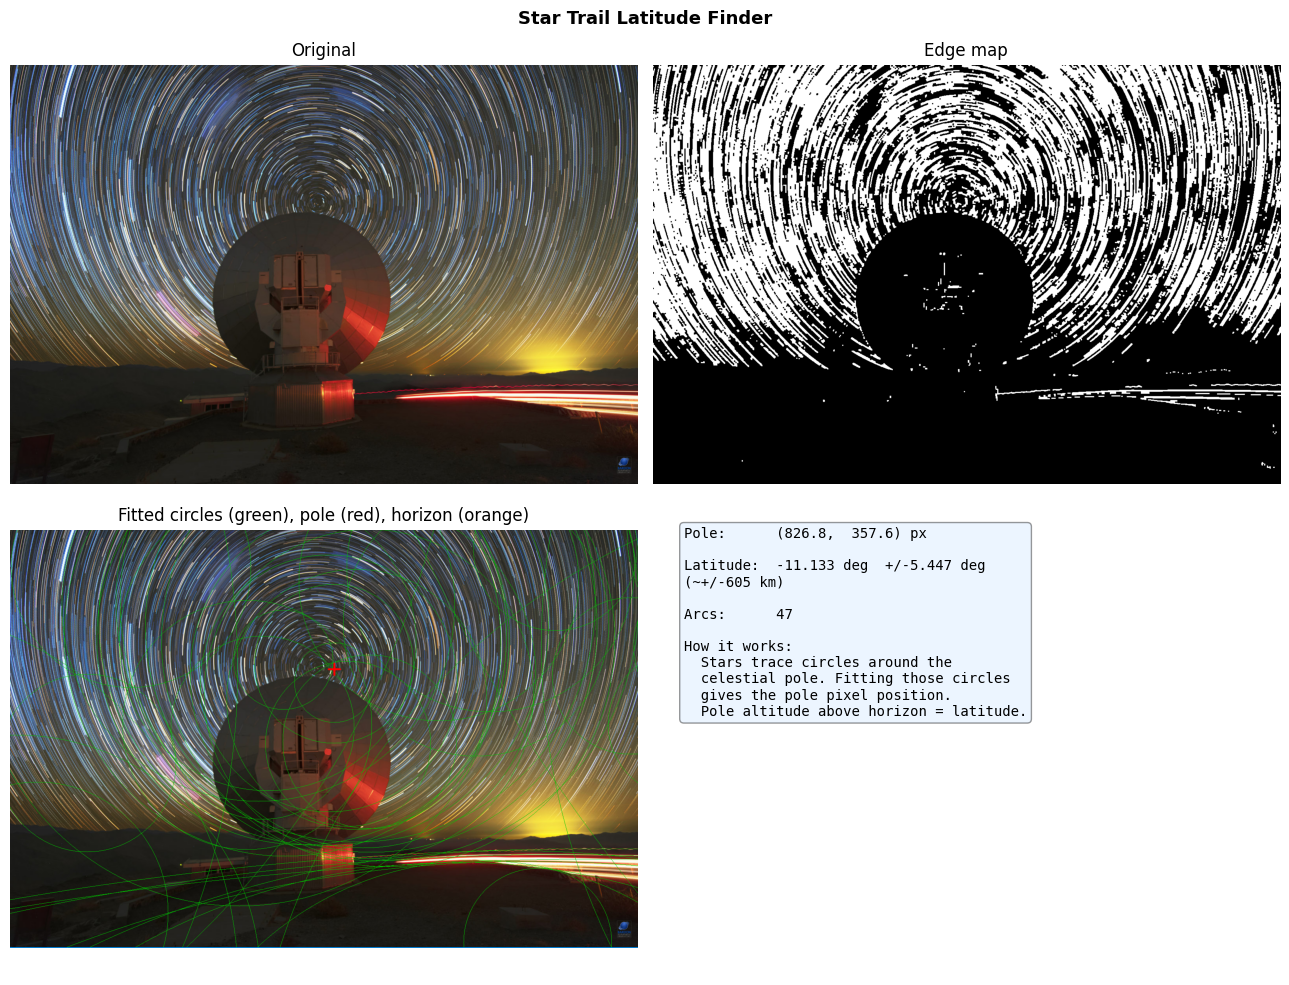

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import least_squares


class LatitudeFinder:

    def __init__(self, image_path, focal_length_mm=None, pixel_size_um=None):
        self.img = cv2.imread(image_path)
        if self.img is None:
            raise ValueError(f"Could not open image: {image_path}")

        self.gray = cv2.cvtColor(self.img, cv2.COLOR_BGR2GRAY)
        self.height, self.width = self.gray.shape

        self.focal_length = focal_length_mm
        self.pixel_size_um = pixel_size_um

        if focal_length_mm and pixel_size_um:
            self.scale_arcsec = 206.265 * pixel_size_um / focal_length_mm
            self.scale_deg = self.scale_arcsec / 3600.0
        else:
            self.scale_arcsec = None
            self.scale_deg = None

        print(f"Image loaded: {self.width} x {self.height}")
        if self.scale_arcsec:
            print(f"Plate scale: {self.scale_arcsec:.2f} arcsec/px")

    def _enhance(self):
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        eq = clahe.apply(self.gray)
        denoised = cv2.bilateralFilter(eq, 9, 75, 75)
        blurred = cv2.GaussianBlur(denoised, (0, 0), 3)
        return cv2.addWeighted(denoised, 1.5, blurred, -0.5, 0)

    def _edges(self, enhanced):
        med = np.median(enhanced)
        canny = cv2.Canny(enhanced, int(max(0, 0.5 * med)), int(min(255, 1.5 * med)))

        sx = cv2.Sobel(enhanced, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(enhanced, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(sx**2 + sy**2)
        mag = np.uint8(255 * mag / (mag.max() + 1e-9))
        _, sobel = cv2.threshold(mag, 40, 255, cv2.THRESH_BINARY)

        combined = cv2.bitwise_or(canny, sobel)
        k = np.ones((3, 3), np.uint8)
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k)
        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, k)
        return combined

    def _get_arcs(self, edges, min_length=50):
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        arcs = []
        for cnt in contours:
            if cv2.arcLength(cnt, closed=False) >= min_length:
                arcs.append(cnt.reshape(-1, 2).astype(float))
        return arcs

    def _fit_circle(self, pts):
        # algebraic fit first
        x, y = pts[:, 0], pts[:, 1]
        A = np.column_stack([2*x, 2*y, np.ones(len(x))])
        b = x**2 + y**2
        try:
            res, _, rank, _ = np.linalg.lstsq(A, b, rcond=None)
        except np.linalg.LinAlgError:
            return None
        if rank < 3:
            return None
        cx, cy = res[0], res[1]
        r = math.sqrt(max(0, res[2] + cx**2 + cy**2))

        # refine with nonlinear least squares
        def residuals(p):
            return np.sqrt((pts[:, 0] - p[0])**2 + (pts[:, 1] - p[1])**2) - p[2]
        try:
            refined = least_squares(residuals, [cx, cy, r], method='lm', max_nfev=500)
            cx, cy, r = refined.x
            r = abs(r)
        except Exception:
            pass

        return cx, cy, r

    def _find_circles(self, arcs):
        diag = math.sqrt(self.width**2 + self.height**2)
        circles = []

        for pts in arcs:
            if len(pts) < 15:
                continue

            step = max(1, len(pts) // 200)
            sample = pts[::step]
            if len(sample) < 5:
                continue

            fit = self._fit_circle(sample)
            if fit is None:
                continue
            cx, cy, r = fit

            # throw out circles that are too small or absurdly large
            if r < 0.05 * diag or r > 5 * diag:
                continue

            # throw out noisy fits
            d = np.sqrt((sample[:, 0] - cx)**2 + (sample[:, 1] - cy)**2)
            if np.std(d - r) > 5:
                continue

            weight = len(pts) / (r + 1e-9)
            circles.append((cx, cy, r, weight))

        return circles

    def _find_pole(self, circles):
        if len(circles) < 3:
            return None

        cxs = np.array([c[0] for c in circles])
        cys = np.array([c[1] for c in circles])
        rs  = np.array([c[2] for c in circles])
        raw_ws = np.array([c[3] for c in circles])

        # subtended angle (radians) = arc_length / r
        # raw weight was arc_len / r, so raw_w * r = arc_len
        # squaring down-weights short arcs heavily
        arc_lengths = raw_ws * rs
        subtended   = arc_lengths / (rs + 1e-9)
        ws = subtended ** 2

        # outlier rejection via MAD:
        # drop any circle whose center is more than 3*MAD away
        # from the median center position
        med_x = np.median(cxs)
        med_y = np.median(cys)
        dists = np.sqrt((cxs - med_x)**2 + (cys - med_y)**2)
        mad = np.median(dists)
        threshold = 3.0 * mad if mad > 0 else np.inf
        keep = dists <= threshold

        if keep.sum() < 3:
            print("  Warning: MAD threshold too tight, relaxing to 6*MAD")
            keep = dists <= 6.0 * mad

        n_rejected = int((~keep).sum())
        if n_rejected > 0:
            print(f"  Rejected {n_rejected} outlier circle center(s)")

        cxs, cys, ws = cxs[keep], cys[keep], ws[keep]
        ws = ws / ws.sum()

        pole_x = np.average(cxs, weights=ws)
        pole_y = np.average(cys, weights=ws)

        ux = math.sqrt(np.average((cxs - pole_x)**2, weights=ws))
        uy = math.sqrt(np.average((cys - pole_y)**2, weights=ws))
        uncertainty = math.sqrt(ux**2 + uy**2)

        return pole_x, pole_y, uncertainty

    def run(self, hemisphere='north', horizon_y_px=None):
        print("\nStep 1: Enhancing image...")
        enhanced = self._enhance()

        print("Step 2: Finding edges...")
        edges = self._edges(enhanced)

        print("Step 3: Extracting arcs...")
        arcs = self._get_arcs(edges)
        print(f"  {len(arcs)} arc candidates")

        if len(arcs) < 5:
            print("Not enough arcs found. Try a longer exposure or darker sky.")
            return

        print("Step 4: Fitting circles...")
        circles = self._find_circles(arcs)
        print(f"  {len(circles)} good fits")

        if len(circles) < 3:
            print("Too few valid circle fits. Image may be too noisy.")
            return

        print("Step 5: Finding pole...")
        pole = self._find_pole(circles)
        if pole is None:
            print("Could not locate the pole.")
            return

        pole_x, pole_y, pole_err = pole
        print(f"  Pole at ({pole_x:.1f}, {pole_y:.1f}) px  +/-{pole_err:.1f} px")

        # compute latitude
        latitude = None
        lat_err  = None

        if self.scale_deg is not None:
            if horizon_y_px is None:
                horizon_y_px = float(self.height - 1)
                print("  No horizon given - using image bottom edge as proxy")

            delta_px = horizon_y_px - pole_y
            latitude = delta_px * self.scale_deg
            lat_err  = pole_err * self.scale_deg

            if hemisphere.lower() == 'south':
                latitude = -abs(latitude)

        # print summary
        print("\n========== RESULTS ==========")
        print(f"Pole position : ({pole_x:.1f}, {pole_y:.1f}) px")
        print(f"Uncertainty   : +/-{pole_err:.1f} px")

        if latitude is not None:
            print(f"Latitude      : {latitude:.3f}  +/-{lat_err:.3f} degrees  (~+/-{lat_err*111:.0f} km)")
            z = abs(latitude)
            zone = "Arctic/Antarctic" if z > 66.5 else ("Temperate" if z > 23.5 else "Tropical")
            print(f"Zone          : {zone}")
        else:
            print("Latitude      : n/a (no plate scale supplied)")

        print(f"Arcs used     : {len(circles)}")
        print("==============================")

        self._plot(edges, circles, pole_x, pole_y, latitude, lat_err, horizon_y_px)

    def _plot(self, edges, circles, pole_x, pole_y, latitude, lat_err, horizon_y_px):
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))
        fig.suptitle("Star Trail Latitude Finder", fontsize=13, fontweight='bold')

        axes[0, 0].imshow(cv2.cvtColor(self.img, cv2.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')

        axes[0, 1].imshow(edges, cmap='gray')
        axes[0, 1].set_title("Edge map")
        axes[0, 1].axis('off')

        overlay = self.img.copy()
        for cx, cy, r, _ in circles:
            cv2.circle(overlay, (int(cx), int(cy)), int(r), (0, 200, 0), 1)
        cv2.drawMarker(overlay, (int(pole_x), int(pole_y)),
                       (0, 0, 255), cv2.MARKER_CROSS, 30, 3)
        if horizon_y_px is not None:
            cv2.line(overlay, (0, int(horizon_y_px)),
                     (self.width, int(horizon_y_px)), (255, 150, 0), 2)
        axes[1, 0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[1, 0].set_title("Fitted circles (green), pole (red), horizon (orange)")
        axes[1, 0].axis('off')

        axes[1, 1].axis('off')
        if latitude is not None:
            lat_str = f"{latitude:+.3f} deg  +/-{lat_err:.3f} deg\n(~+/-{lat_err*111:.0f} km)"
        else:
            lat_str = "n/a - supply focal_length + pixel_size"

        summary = (
            f"Pole:      ({pole_x:.1f},  {pole_y:.1f}) px\n\n"
            f"Latitude:  {lat_str}\n\n"
            f"Arcs:      {len(circles)}\n\n"
            f"How it works:\n"
            f"  Stars trace circles around the\n"
            f"  celestial pole. Fitting those circles\n"
            f"  gives the pole pixel position.\n"
            f"  Pole altitude above horizon = latitude."
        )
        axes[1, 1].text(0.05, 0.95, summary,
                        transform=axes[1, 1].transAxes,
                        fontsize=10, va='top', fontfamily='monospace',
                        bbox=dict(boxstyle='round', facecolor='#d0e8ff', alpha=0.4))

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    image_path   = "your_night_sky.jpg"   # change this to your image path
    focal_length = 18                     # Zeiss Milvus 2.8/18
    pixel_size   = 4.93                   # Nikon D810A
    hemisphere   = 'south'                # 'north' or 'south'

    # open the image in any editor, find the pixel row of the horizon,
    # and set it here. leave as None to fall back to the bottom edge.
    horizon_y_px = None
    

    finder = LatitudeFinder(image_path, focal_length, pixel_size)
    finder.run(hemisphere=hemisphere, horizon_y_px=horizon_y_px)